## SITCOM-2079: Rubin thermal analysis ComCam
### Karla Peña Ramírez
May 7 2025


Temperature control is essential to protect components sensitive to high temperatures and to prevent adding thermal load to the dome, which could impact image quality. All components are thermally insulated or have an integrated thermal control system. The temperature of these components must be maintained within a range of +1C/-2C with respect to the local ambient air temperature, regulated by TMA’s glycol/water thermal control system. The above mentioned temperature range should also be confirmed in all cases where the differences in temperature are traced between surfaces and air temperature (except within the mirrors where the ideal condition is to be isothermal).

This ticket studies the available temperature sensors in the Simonyi Telescope during the ComCam campaign starting on October 17 2024 and ending on December 12 2024.

In [1]:
#Setting packages
import asyncio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import time
import warnings
import seaborn as sns
import datetime as dt
from scipy import stats
from matplotlib.dates import DateFormatter
from astropy.table import Table, join
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from scipy.cluster.hierarchy import dendrogram, linkage
from lsst.utils.packages import getEnvironmentPackages
from IPython.display import Markdown, display
#%matplotlib widget

from astropy.time import Time, TimeDelta
from lsst.daf.butler import Butler 
#from tqdm.notebook import tqdm


from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge
from sklearn.model_selection import ShuffleSplit
import warnings

# Ignore the many warning messages from ``merge_packed_time_series``
warnings.simplefilter(action="ignore", category=FutureWarning)

#-------Clients
from lsst_efd_client import EfdClient
client = EfdClient("usdf_efd")

#from lsst.summit.utils.efdUtils import makeEfdClient
#client = makeEfdClient()

#from lsst.summit.utils import ConsDbClient
#os.environ["no_proxy"] += ",.consdb"
#url="http://consdb-pq.consdb:8080/consdb"
#consdb=ConsDbClient(url)
#-------Clients

def print_session_info():
    # Time info
    print(f"# Session Info on {time.strftime('%Y-%m-%d at %H:%M:%S %Z', time.localtime(time.time()))}\n")

    # Python info
    print(f"## Python Interpreter\n\nVersion: {sys.version}  \nExecutable: {sys.executable}\n")

    # LSST info
    packages = getEnvironmentPackages(True)
    dev_packages = {"lsst_distrib": packages["lsst_distrib"]}
    dev_packages.update({k: v.split("@")[0] for k, v in packages.items() if "LOCAL" in v})
    print("## Science Pipelines\n\n" + "\n".join(f"{k:<20} {v}" for k, v in dev_packages.items()))

## 1. Data retrievals
We are interested on ComCam on-sky. Since at the moment we did not have telemetry for the dome shutter, we are going to use the time stamp of the acquired images as a proxy of on-sky dome aperture.
### On-sky time ranges:

In [2]:
#Identify the repo where all the data lives and the latest consolidated processing collection
#Run > butler query-collections /repo/main "*DRP*w_2025_0*" | grep CHAINED
repo = '/repo/main'
instrument = "LSSTComCam"
collection = 'LSSTComCam/runs/DRP/DP1/w_2025_08/DM-49029'
butler = Butler(repo, collections=collection)
registry = butler.registry

In [3]:
#Query the metadata for the **`exposure`** dimension, limiting the results to this particular instrument and range of days of observation:
instrument = 'LSSTComCam'
day_obs_start = 20241017
day_obs_end = 20241212
query="instrument='%s' AND day_obs>=%d AND day_obs<=%d" % (instrument, day_obs_start, day_obs_end)
results = registry.queryDimensionRecords('exposure', where=query)

In [4]:
#Taken from vv-team-notebooks/reports/TargetReport.ipynb
#Stop executing if there are no results returned:
n_results = results.count()

if n_results <= 0:
    raise StopExecution
else:
    print("""There are %d results returned from querying the butler for instrument %s between dates %d and %d (inclusive).""" % 
          (n_results, instrument, day_obs_start, day_obs_end))

There are 16626 results returned from querying the butler for instrument LSSTComCam between dates 20241017 and 20241212 (inclusive).


In [5]:
#Taken from vv-team-notebooks/reports/TargetReport.ipynb
#Instantiate a pandas `DataFrame` with useful columns available in the `exposure` dimension:
df_exp = pd.DataFrame(columns=['id', 'obs_id','day_obs', 'seq_num',
                                    'time_start','time_end' ,'type', 'reason', 
                                    'target','filter','zenith_angle',
                                    'expos','ra','dec','skyangle',
                                    'azimuth','zenith','science_program',
                                    'jd','mjd'])

In [6]:
#Taken from vv-team-notebooks/reports/TargetReport.ipynb
#Read the query results into the new pandas `DataFrame`:
for count, info in enumerate(results):
    
    try:

        df_exp.loc[count] = [info.id, info.obs_id, info.day_obs, info.seq_num, 
                                  info.timespan.begin.utc.iso,
                                  info.timespan.end.utc.iso, 
                                  info.observation_type, info.observation_reason, info.target_name, 
                                  info.physical_filter, info.zenith_angle, 
                                  info.exposure_time,info.tracking_ra, info.tracking_dec, 
                                  info.sky_angle,info.azimuth ,info.zenith_angle, 
                                  info.science_program, info.timespan.begin.jd, info.timespan.begin.mjd]

    except:
    
        print(">>>   Unexpected error:", sys.exc_info()[0])
        info_timespan_begin_to_string = "2021-01-01 00:00:00.00"
        info_timespan_end_to_string = "2051-01-01 00:00:00.00"
        info_timespan_begin_jd = 0
        info_timespan_begin_mjd = 0
        df_exp.loc[count] = [info.id, info.obs_id, info.day_obs, info.seq_num, 
                                  pd.to_datetime(info_timespan_begin_to_string),
                                  pd.to_datetime(info_timespan_end_to_string), 
                                  info.observation_type, info.observation_reason, info.target_name, 
                                  info.physical_filter, info.zenith_angle, 
                                  info.exposure_time,info.tracking_ra, info.tracking_dec, 
                                  info.sky_angle,info.azimuth ,info.zenith_angle, 
                                  info.science_program, info_timespan_begin_jd, info_timespan_begin_mjd ]    

In [7]:
#Taken from vv-team-notebooks/reports/TargetReport.ipynb
#Clean-up the dataframe
#Re-cast the `id`, `day_obs`, and `seq_num` rows as `int`'s:
df_exp = df_exp.astype({"id": int,'day_obs': int,'seq_num':int})
# Replace `NaN`'s in the `ra` and `dec` columns with zero.  
df_exp['ra'] = df_exp['ra'].fillna(0)
df_exp['dec'] = df_exp['dec'].fillna(0)
#Select only on-sky data
df_exp.type.unique()
df_open = df_exp[(df_exp.type == 'science') | (df_exp.type == 'cwfs') | (df_exp.type == 'focus') | (df_exp.type == 'acq')| (df_exp.type == 'flat')]

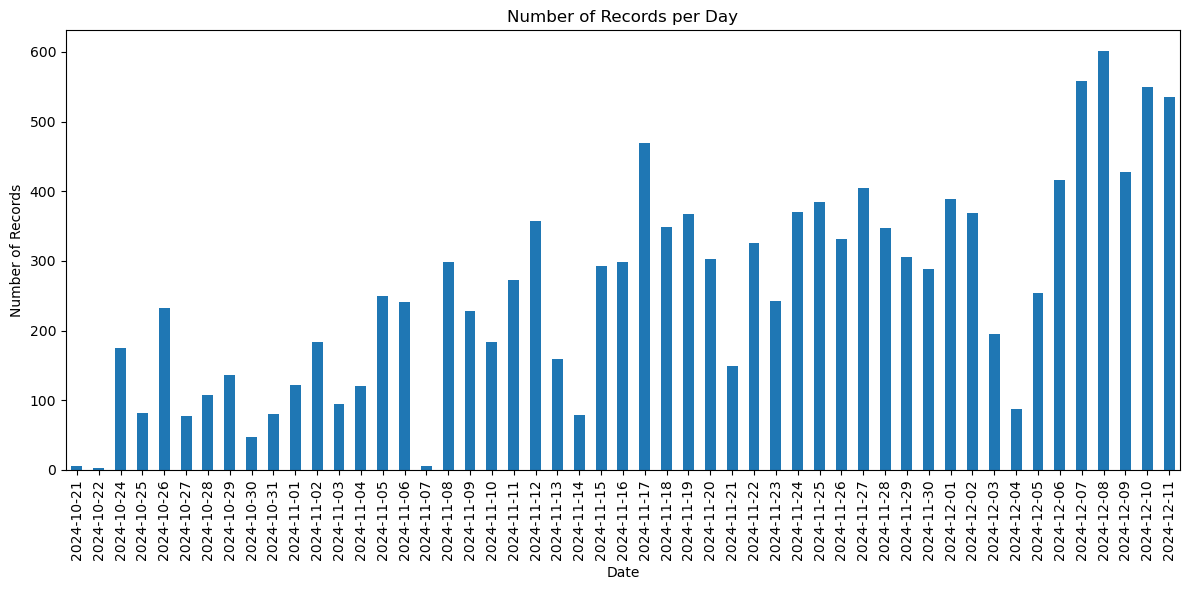

In [8]:
#Count records per day
df_open_records = df_open.copy()
#Convert day_obs to datetime
df_open_records['day_obs'] = pd.to_datetime(df_open_records['day_obs'], format='%Y%m%d')
#Count records per day
daily_counts = df_open_records.groupby(df_open_records['day_obs'].dt.date).size()

plt.figure(figsize=(12, 6))
daily_counts.plot(kind='bar')

plt.title('Number of Records per Day')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.xticks(rotation=90)
plt.tight_layout()

In [9]:
#Group data by dayobs identifying the extremme dates for the exposures.
result_on_sky = df_open.groupby('day_obs').agg({
    'time_start': 'min',
    'time_end': 'max'
}).reset_index()

In [10]:
def read_time_data():
    df = result_on_sky
    df['time_start'] = pd.to_datetime(df['time_start'])
    df['time_end'] = pd.to_datetime(df['time_end'])
    return df
    
def get_time_range(df, day_obs):
    day_data = df[df['day_obs'] == day_obs].iloc[0]
    return day_data['time_start'], day_data['time_end']

### Telemetry retrieval:

In [11]:
async def get_dynalene_data(client, day_obs, sampling="1h"):
    """Get dynalene data for a specific day_obs."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(dynTMAsupTS01) AS TMA_Supply_Dynalene, 
        mean(dynTMAretTS02) AS TMA_Return_Dynalene, 
        mean(dynCH01supTS05) AS Test_Chiller_1
    FROM "lsst.sal.HVAC.dynaleneP05" 
    WHERE time > '{start_time.isoformat()}Z' 
    AND time < '{end_time.isoformat()}Z' 
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_dynalene_mtmount(client, day_obs, sampling="1h"):
    """Get MTMount dynalene data for a specific day_obs."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(dynaleneTemperatureAzimuth0001) AS TMA_Azimuth_1,
        mean(dynaleneTemperatureAzimuth0002) AS TMA_Azimuth_2,
        mean(dynaleneTemperaturePier0102) AS TMA_Pier_2
    FROM "lsst.sal.MTMount.dynaleneCooling"
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_ess_1(client, day_obs, sampling="1h"):
    """Get ESS temperature data for CamHex and CamRot."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureItem0) AS CamHex_Strut_7,
        mean(temperatureItem1) AS CamHex_Strut_8,
        mean(temperatureItem2) AS CamHex_Strut_9,
        mean(temperatureItem3) AS CamHex_Strut_10,
        mean(temperatureItem4) AS CamHex_Strut_11,
        mean(temperatureItem5) AS CamHex_Strut_12,
        mean(temperatureItem6) AS CamRot_Motor_1,
        mean(temperatureItem7) AS CamRot_Motor_2
    FROM "lsst.sal.ESS.temperature"
    WHERE salIndex = 1
    AND time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_ess_106(client, day_obs, sampling="1h"):
    """Get ESS temperature data for M2 Tangent Links."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureItem0) AS M2_Tangent_Link_A1,
        mean(temperatureItem1) AS M2_Tangent_Link_A2,
        mean(temperatureItem2) AS M2_Tangent_Link_A3,
        mean(temperatureItem3) AS M2_Tangent_Link_A4,
        mean(temperatureItem4) AS M2_Tangent_Link_A5,
        mean(temperatureItem5) AS M2_Tangent_Link_A6
    FROM "lsst.sal.ESS.temperature"
    WHERE salIndex = 106
    AND time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)

async def get_ess_112(client, day_obs, sampling="1h"):
    """Get ESS temperature data for M2."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureItem0) AS ESS_112_M2
    FROM "lsst.sal.ESS.temperature"
    WHERE salIndex = 112
    AND time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_ess_111(client, day_obs, sampling="1h"):
    """Get ESS temperature data for Camera."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureItem0) AS ESS_111_Camera
    FROM "lsst.sal.ESS.temperature"
    WHERE salIndex = 111
    AND time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_ess_113(client, day_obs, sampling="1h"):
    """Get ESS temperature data for Dome."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureItem0) AS ESS_113_Dome
    FROM "lsst.sal.ESS.temperature"
    WHERE salIndex = 113
    AND time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_ess_301(client, day_obs, sampling="1h"):
    """Get ESS temperature data for Outside Dome."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureItem0) AS Outside_Dome
    FROM "lsst.sal.ESS.temperature"
    WHERE salIndex = 301
    AND time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_mtmount_topend_chiller(client, day_obs, sampling="1h"):
    """Get MTMount TopEndChiller temperature data."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(temperatureSensor0501) AS Temperature_0501,
        mean(ambientTemperatureSensor0502) AS Ambient_0502,
        mean(ductTemperatureSensor0506) AS Duct_0506,
        mean(ductTemperatureSensor0507) AS Duct_0507,
        mean(internalTemperatureElectricalCabinet0) AS Internal_Cabinet_0,
        mean(internalTemperatureElectricalCabinet1) AS Internal_Cabinet_1,
        mean(externalTemperatureElectricalCabinet1) AS External_Cabinet_1,
        mean(internalTemperatureElectricalCabinet3) AS Internal_Cabinet_3,
        mean(externalTemperatureElectricalCabinet3) AS External_Cabinet_3
    FROM "lsst.sal.MTMount.topEndChiller"
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_m2_temps(client, day_obs, sampling="1h"):
    """Get M2 temperature data."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(intake0) as M2_Intake0,
        mean(intake1) as M2_Intake1,
        mean(exhaust0) as M2_Exhaust0,
        mean(exhaust1) as M2_Exhaust1,
        mean(ring5) as M2_ring
    FROM "lsst.sal.MTM2.temperature"
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_m1m3_glycol(client, day_obs, sampling="1h"):
    """Get M1M3 glycol temperature data."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean(telescopeCoolantReturnTemperature) as TMA_Coolant_Retun,
        mean(telescopeCoolantSupplyTemperature) as TMA_Coolant_Supply,
        mean(mirrorCoolantSupplyTemperature) as M1M3_Coolant_Supply,
        mean(mirrorCoolantReturnTemperature) as M1M3_Coolant_Return,
        mean(insideCellTemperature1) as Interior_Cell_1,
        mean(insideCellTemperature2) as Interior_Cell_2,
        mean(insideCellTemperature3) as Interior_Cell_3
    FROM "lsst.sal.MTM1M3TS.glycolLoopTemperature"
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)


async def get_m1m3_fcu(client, day_obs, sampling="1h"):
    """Get M1M3 FCU temperature data."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    
    query = f"""
    SELECT 
        mean("absoluteTemperature20") AS "FCU20",
        mean("absoluteTemperature50") AS "FCU50",
        mean("absoluteTemperature80") AS "FCU80"
    FROM "lsst.sal.MTM1M3TS.thermalData"
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)    


async def get_glycolMTMount(client, day_obs, sampling="1h"):
    """Get MTMount glycol general purpose temperature data."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    query = f"""
    SELECT 
        mean(glycolTemperaturePier0001) AS General_Glycol_L6_1,
        mean(glycolTemperaturePier0002) AS General_Glycol_L6_2
    FROM "lsst.sal.MTMount.generalPurposeGlycolWater" 
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)    


async def get_coldglycolMTMount(client, day_obs, sampling="1h"):
    """Get MTMount cold glycol temperature data."""
    df = read_time_data()
    start_time, end_time = get_time_range(df, int(day_obs))
    query = f"""
    SELECT 
        mean(glycolTemperaturePier0101) AS Cold_Glycol_L6
    FROM "lsst.sal.MTMount.cooling" 
    WHERE time > '{start_time.isoformat()}Z'
    AND time < '{end_time.isoformat()}Z'
    GROUP BY time({sampling})
    """
    results = await client.influx_client.query(query)
    return pd.DataFrame(results)    


### Determine the date of interest and the sampling rate:

In [12]:
#Single day data:
sampling = '1m'
day_to_check = '20241208'

#Dynalene data
dynalene = await get_dynalene_data(client, sampling = sampling, day_obs=day_to_check)
dynaleneMTMount = await get_dynalene_mtmount(client, sampling = sampling, day_obs=day_to_check)
#ESS temperature data
ESS_1 = await get_ess_1(client, sampling = sampling, day_obs=day_to_check)  # CamHex and CamRot
ESS_106 = await get_ess_106(client, sampling = sampling, day_obs=day_to_check)  # M2 Tangent Links
ESS_112 = await get_ess_112(client, sampling = sampling, day_obs=day_to_check)  # M2
ESS_111 = await get_ess_111(client, sampling = sampling, day_obs=day_to_check)  # Camera
ESS_113 = await get_ess_113(client, sampling = sampling, day_obs=day_to_check)  # Dome
ESS_301 = await get_ess_301(client, sampling = sampling, day_obs=day_to_check)  # Outside Dome
#MTMount TopEndChiller data
MTMountTopEndChiller = await get_mtmount_topend_chiller(client, sampling = sampling, day_obs=day_to_check)
#M2 temperature data
M2Temps = await get_m2_temps(client, sampling = sampling, day_obs=day_to_check)
#M1M3 data
M1M3_glycol = await get_m1m3_glycol(client, sampling = sampling, day_obs=day_to_check)  # Glycol temperatures
M1M3_FCU = await get_m1m3_fcu(client, sampling = sampling, day_obs=day_to_check)  # FCU temperatures
mask1 = M1M3_FCU['FCU20'] <= 100
mask2 = M1M3_FCU['FCU50'] <= 100
mask3 = M1M3_FCU['FCU80'] <= 100
M1M3_FCU_red1 = M1M3_FCU[mask1]
M1M3_FCU_red2 = M1M3_FCU[mask2]
M1M3_FCU_red3 = M1M3_FCU[mask3]
#Glycol
glycolMTMount = await get_glycolMTMount(client, sampling = sampling, day_obs=day_to_check)
coldglycolMTMount = await get_coldglycolMTMount(client, sampling = sampling, day_obs=day_to_check)

#Single day
data_objects = [
M1M3_glycol['M1M3_Coolant_Return'],
M1M3_FCU_red1['FCU20'],
M1M3_FCU_red2['FCU50'],
M1M3_FCU_red3['FCU80'],
M1M3_glycol['Interior_Cell_3'],
M1M3_glycol['Interior_Cell_1'],
M1M3_glycol['Interior_Cell_2'],
ESS_301['Outside_Dome'],
ESS_106['M2_Tangent_Link_A6'],
ESS_106['M2_Tangent_Link_A2'],
ESS_106['M2_Tangent_Link_A4'],
MTMountTopEndChiller['External_Cabinet_3'],
MTMountTopEndChiller['Duct_0507'],
MTMountTopEndChiller['Ambient_0502'],
MTMountTopEndChiller['Duct_0506'],
M2Temps['M2_Exhaust0'],
M2Temps['M2_Intake1'],
M2Temps['M2_Exhaust1'],
M2Temps['M2_Intake0'],
MTMountTopEndChiller['Temperature_0501'],
ESS_113['ESS_113_Dome'],
MTMountTopEndChiller['External_Cabinet_1'],
ESS_112['ESS_112_M2'],
ESS_111['ESS_111_Camera'],
ESS_106['M2_Tangent_Link_A5'],
ESS_106['M2_Tangent_Link_A3'],
M2Temps['M2_ring'],
ESS_1['CamRot_Motor_1'],    
ESS_1['CamRot_Motor_2'],
ESS_1['CamHex_Strut_11'],
ESS_1['CamHex_Strut_7'],
ESS_1['CamHex_Strut_8'],
ESS_1['CamHex_Strut_12'],
ESS_1['CamHex_Strut_9'],
ESS_1['CamHex_Strut_10'],
M1M3_glycol['TMA_Coolant_Supply'],
M1M3_glycol['TMA_Coolant_Retun'],
M1M3_glycol['M1M3_Coolant_Supply'],
MTMountTopEndChiller['Internal_Cabinet_0'],
MTMountTopEndChiller['Internal_Cabinet_1'],
MTMountTopEndChiller['Internal_Cabinet_3'],
dynaleneMTMount['TMA_Pier_2'],
dynalene['TMA_Return_Dynalene'],
dynaleneMTMount['TMA_Azimuth_2'],
dynalene['Test_Chiller_1'],
dynaleneMTMount['TMA_Azimuth_1'],
dynalene['TMA_Supply_Dynalene'],
glycolMTMount['General_Glycol_L6_1'],
glycolMTMount['General_Glycol_L6_2'],  
coldglycolMTMount['Cold_Glycol_L6']
]

df = pd.concat(data_objects, axis=1)
df.shape

(981, 50)

## 2. Visual data exploration 
Let's make a basic data exploration plotting the queries vs. time:

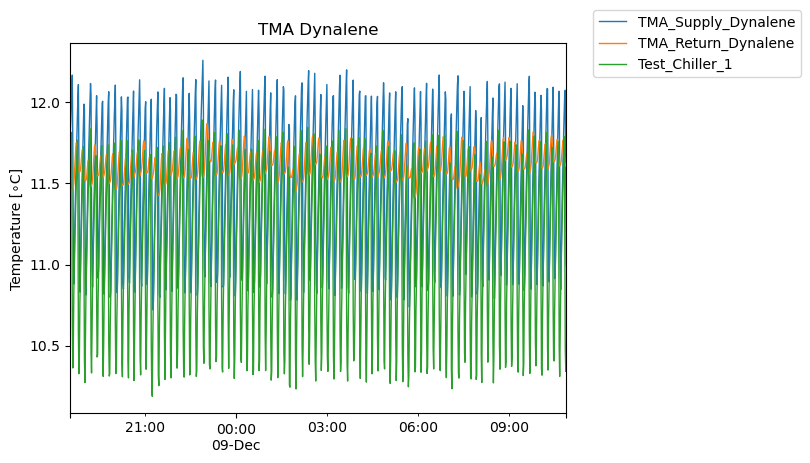

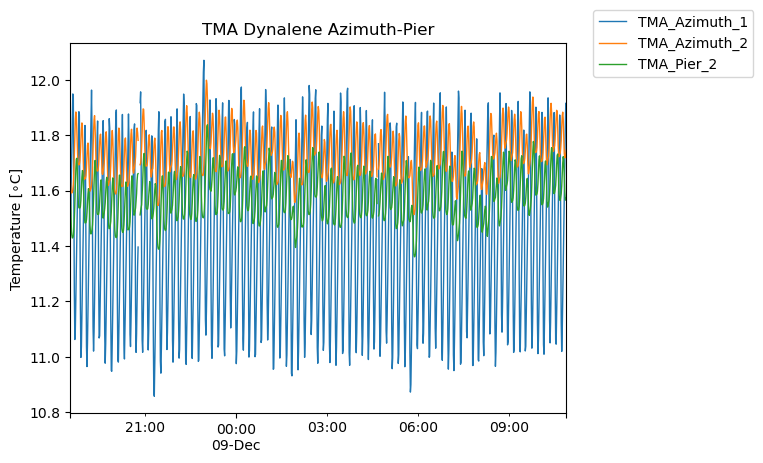

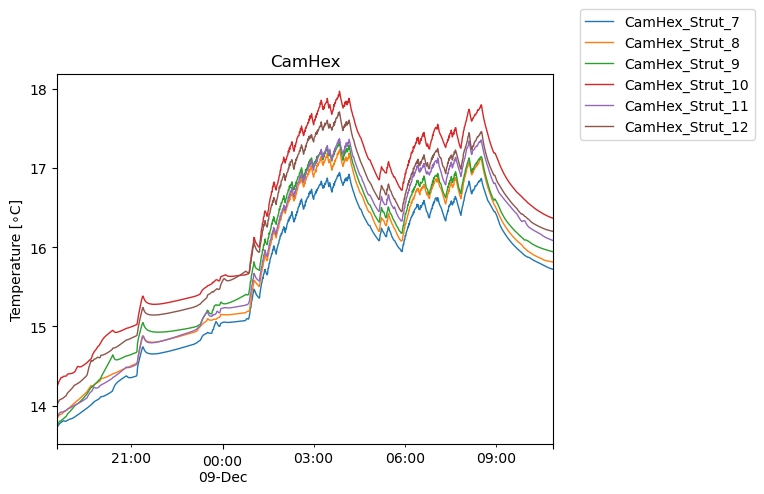

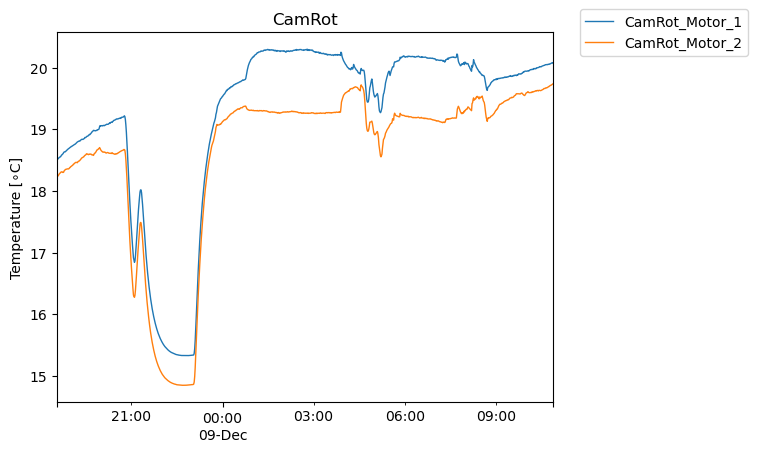

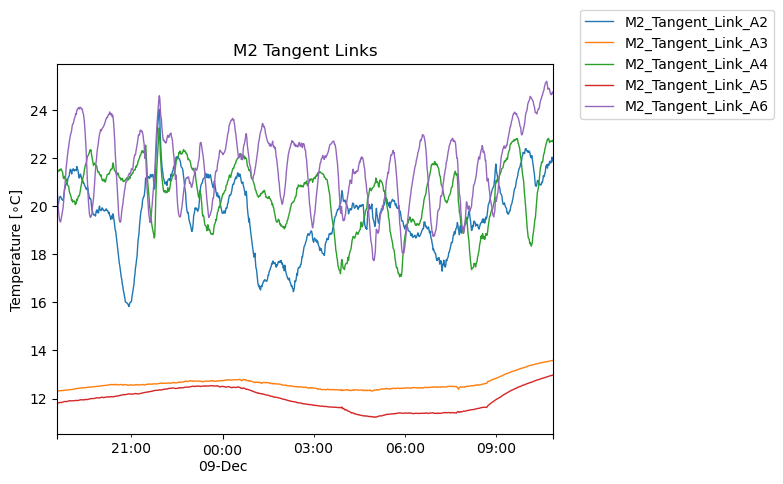

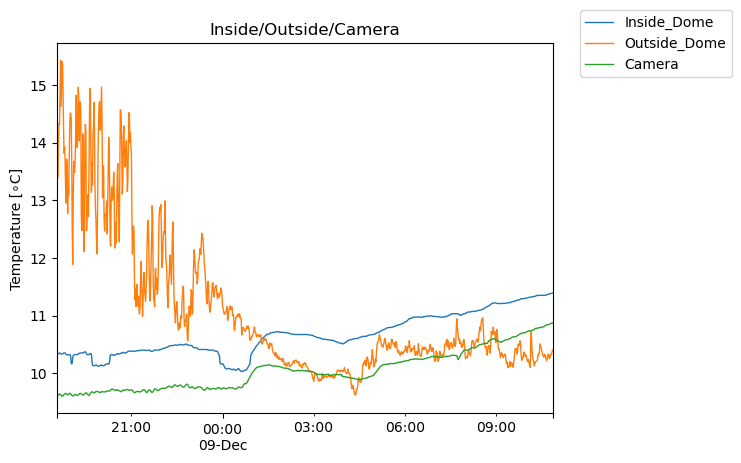

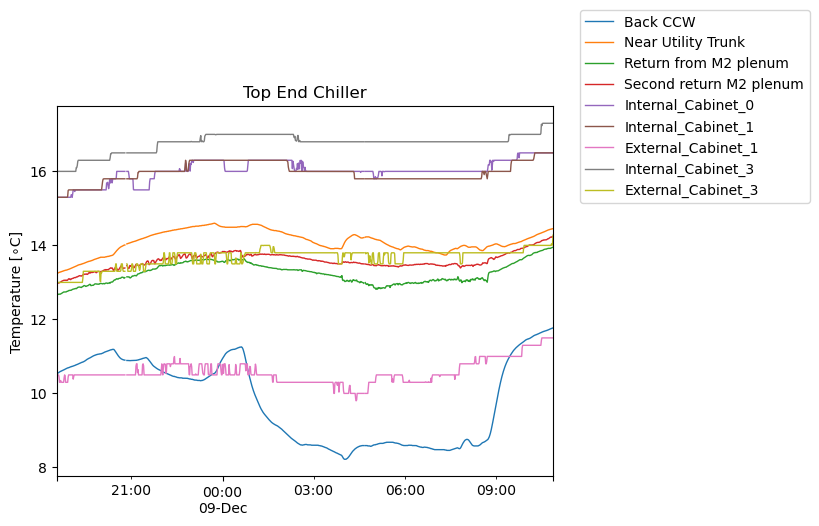

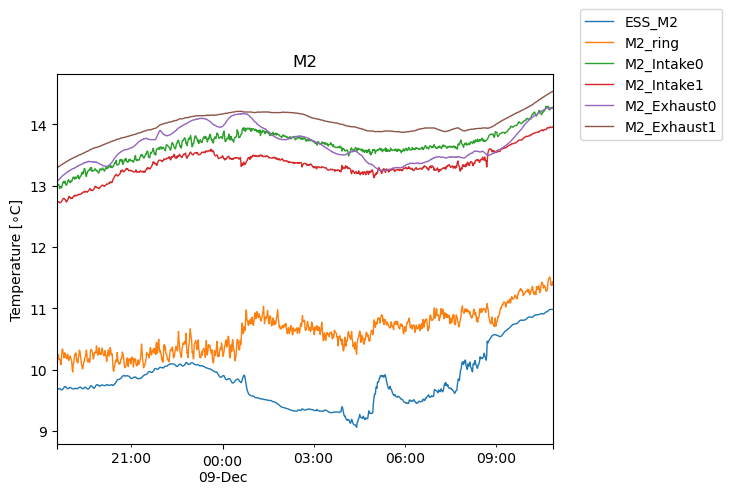

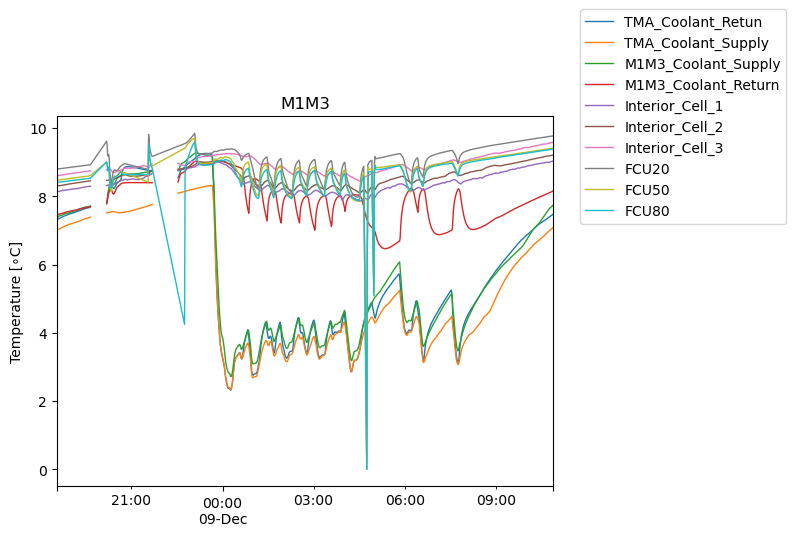

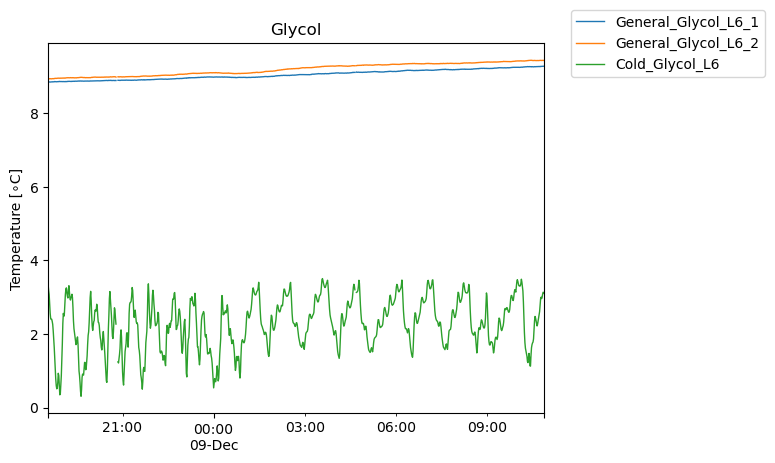

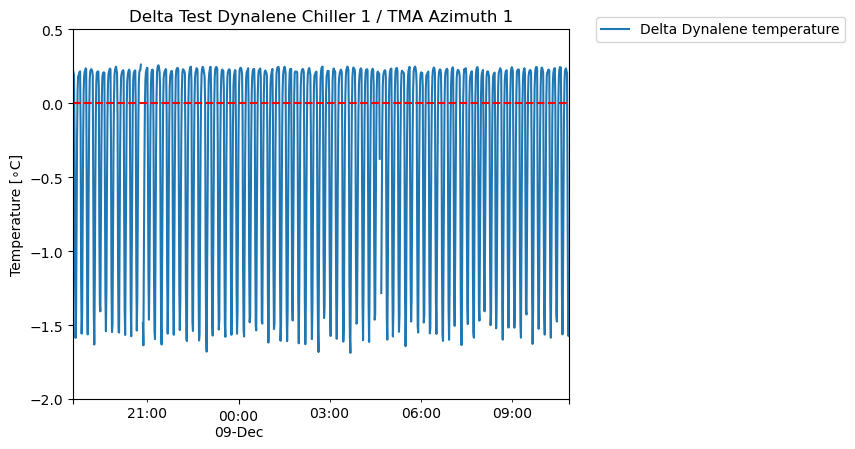

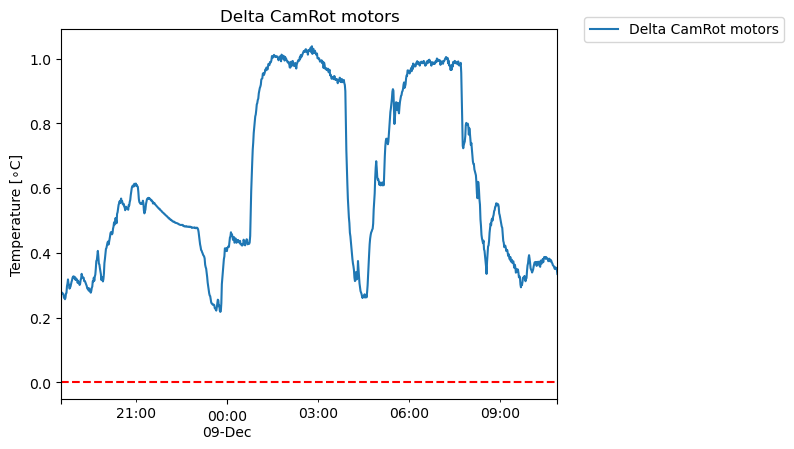

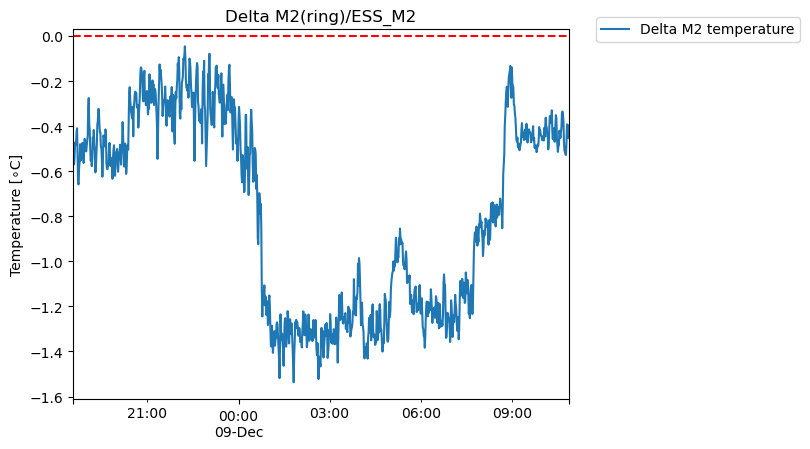

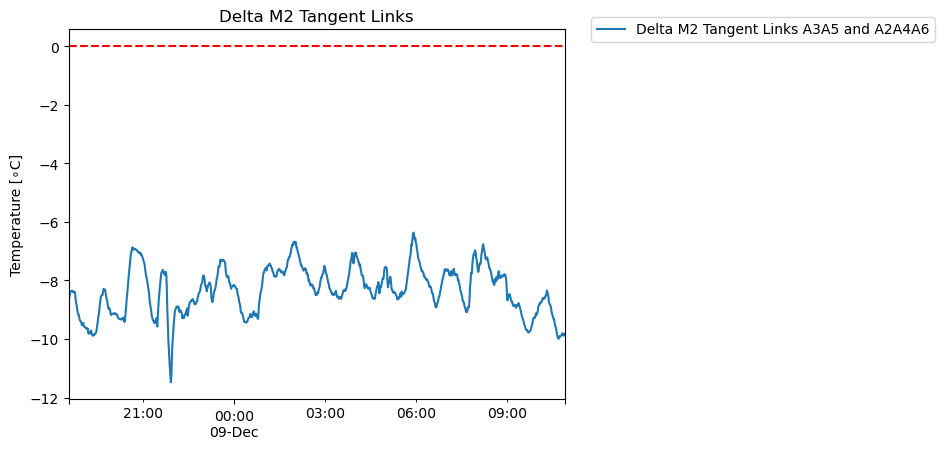

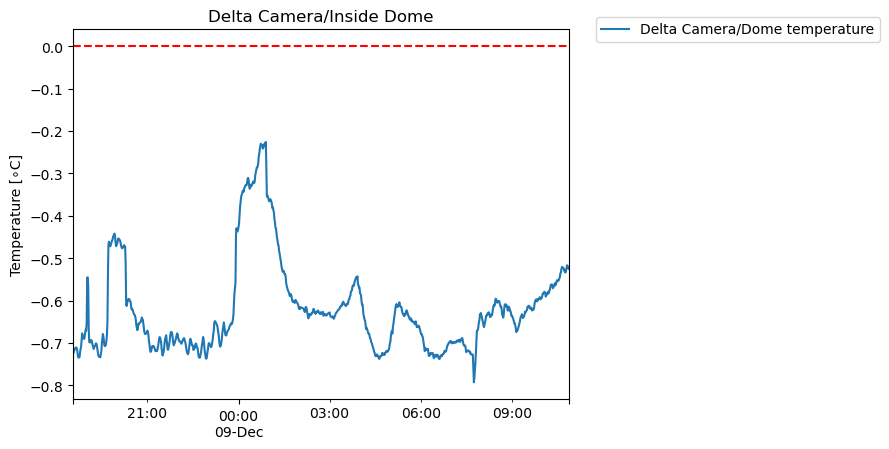

In [13]:
#Raw figures.
#TMA Dynalene
plt.title('TMA Dynalene')
ax = dynalene['TMA_Supply_Dynalene'].plot(linewidth=1, label='TMA_Supply_Dynalene')
ax = dynalene['TMA_Return_Dynalene'].plot(linewidth=1, label='TMA_Return_Dynalene')
ax = dynalene['Test_Chiller_1'].plot(linewidth=1, label='Test_Chiller_1')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#TMA Dynalene Azimuth-Pier
plt.title('TMA Dynalene Azimuth-Pier')
ax = dynaleneMTMount['TMA_Azimuth_1'].plot(linewidth=1, label='TMA_Azimuth_1')
ax = dynaleneMTMount['TMA_Azimuth_2'].plot(linewidth=1, label='TMA_Azimuth_2')
ax = dynaleneMTMount['TMA_Pier_2'].plot(linewidth=1, label='TMA_Pier_2')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Camera Hexapods
plt.title('CamHex')
ax = ESS_1['CamHex_Strut_7'].plot(linewidth=1, label='CamHex_Strut_7')
ax = ESS_1['CamHex_Strut_8'].plot(linewidth=1, label='CamHex_Strut_8')
ax = ESS_1['CamHex_Strut_9'].plot(linewidth=1, label='CamHex_Strut_9')
ax = ESS_1['CamHex_Strut_10'].plot(linewidth=1, label='CamHex_Strut_10')
ax = ESS_1['CamHex_Strut_11'].plot(linewidth=1, label='CamHex_Strut_11')
ax = ESS_1['CamHex_Strut_12'].plot(linewidth=1, label='CamHex_Strut_12')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Camera Rotator
plt.title('CamRot')
ax = ESS_1['CamRot_Motor_1'].plot(linewidth=1, label='CamRot_Motor_1')
ax = ESS_1['CamRot_Motor_2'].plot(linewidth=1, label='CamRot_Motor_2')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#M2 Tangent Links
plt.title('M2 Tangent Links')
#ax = ESS_106['M2_Tangent_Link_A1'].plot(linewidth=1, label='M2_Tangent_Link_A1')
ax = ESS_106['M2_Tangent_Link_A2'].plot(linewidth=1, label='M2_Tangent_Link_A2')
ax = ESS_106['M2_Tangent_Link_A3'].plot(linewidth=1, label='M2_Tangent_Link_A3')
ax = ESS_106['M2_Tangent_Link_A4'].plot(linewidth=1, label='M2_Tangent_Link_A4')
ax = ESS_106['M2_Tangent_Link_A5'].plot(linewidth=1, label='M2_Tangent_Link_A5')
ax = ESS_106['M2_Tangent_Link_A6'].plot(linewidth=1, label='M2_Tangent_Link_A6')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Inside/Outside Dome/Camera
plt.title('Inside/Outside/Camera')
ax = ESS_113['ESS_113_Dome'].plot(linewidth=1, label='Inside_Dome')
ax = ESS_301['Outside_Dome'].plot(linewidth=1, label='Outside_Dome')
ax = ESS_111['ESS_111_Camera'].plot(linewidth=1, label='Camera')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Top End Chiller
plt.title('Top End Chiller')
ax = MTMountTopEndChiller['Temperature_0501'].plot(linewidth=1, label='Back CCW')
ax = MTMountTopEndChiller['Ambient_0502'].plot(linewidth=1, label='Near Utility Trunk')
ax = MTMountTopEndChiller['Duct_0506'].plot(linewidth=1, label='Return from M2 plenum')
ax = MTMountTopEndChiller['Duct_0507'].plot(linewidth=1, label='Second return M2 plenum')
ax = MTMountTopEndChiller['Internal_Cabinet_0'].plot(linewidth=1, label='Internal_Cabinet_0')
ax = MTMountTopEndChiller['Internal_Cabinet_1'].plot(linewidth=1, label='Internal_Cabinet_1')
ax = MTMountTopEndChiller['External_Cabinet_1'].plot(linewidth=1, label='External_Cabinet_1')
ax = MTMountTopEndChiller['Internal_Cabinet_3'].plot(linewidth=1, label='Internal_Cabinet_3')
ax = MTMountTopEndChiller['External_Cabinet_3'].plot(linewidth=1, label='External_Cabinet_3')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#M2
plt.title('M2')
ax = ESS_112['ESS_112_M2'].plot(linewidth=1, label='ESS_M2')
ax = M2Temps['M2_ring'].plot(linewidth=1, label='M2_ring')
ax = M2Temps['M2_Intake0'].plot(linewidth=1, label='M2_Intake0')
ax = M2Temps['M2_Intake1'].plot(linewidth=1, label='M2_Intake1')
ax = M2Temps['M2_Exhaust0'].plot(linewidth=1, label='M2_Exhaust0')
ax = M2Temps['M2_Exhaust1'].plot(linewidth=1, label='M2_Exhaust1')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#M1M3
plt.title('M1M3')
ax = M1M3_glycol['TMA_Coolant_Retun'].plot(linewidth=1, label='TMA_Coolant_Retun')
ax = M1M3_glycol['TMA_Coolant_Supply'].plot(linewidth=1, label='TMA_Coolant_Supply')
ax = M1M3_glycol['M1M3_Coolant_Supply'].plot(linewidth=1, label='M1M3_Coolant_Supply')
ax = M1M3_glycol['M1M3_Coolant_Return'].plot(linewidth=1, label='M1M3_Coolant_Return')
ax = M1M3_glycol['Interior_Cell_1'].plot(linewidth=1, label='Interior_Cell_1')
ax = M1M3_glycol['Interior_Cell_2'].plot(linewidth=1, label='Interior_Cell_2')
ax = M1M3_glycol['Interior_Cell_3'].plot(linewidth=1, label='Interior_Cell_3')
ax = M1M3_FCU_red1['FCU20'].plot(linewidth=1, label='FCU20')
ax = M1M3_FCU_red2['FCU50'].plot(linewidth=1, label='FCU50')
ax = M1M3_FCU_red3['FCU80'].plot(linewidth=1, label='FCU80')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Glycol
plt.title('Glycol')
ax = glycolMTMount['General_Glycol_L6_1'].plot(linewidth=1, label='General_Glycol_L6_1')
ax = glycolMTMount['General_Glycol_L6_2'].plot(linewidth=1, label='General_Glycol_L6_2')
ax = coldglycolMTMount['Cold_Glycol_L6'].plot(linewidth=1, label='Cold_Glycol_L6')
plt.ylabel('Temperature [∘C]')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()


#Difference in TMA Dynalene temperature by location
plt.title('Delta Test Dynalene Chiller 1 / TMA Azimuth 1')
delta = dynalene['Test_Chiller_1'] - dynaleneMTMount['TMA_Azimuth_1']
ax = delta.plot(linewidth=1.5, label='Delta Dynalene temperature')
plt.ylabel('Temperature [∘C]')
plt.ylim(-2.0, 0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Difference in CamRot motors temperature
plt.title('Delta CamRot motors')
delta = ESS_1['CamRot_Motor_1'] - ESS_1['CamRot_Motor_2']
ax = delta.plot(linewidth=1.5, label='Delta CamRot motors')
plt.ylabel('Temperature [∘C]')
#plt.ylim(-1.0, 0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Difference in M2 temperature by location
plt.title('Delta M2(ring)/ESS_M2')
delta = ESS_112['ESS_112_M2'] - M2Temps['M2_ring']
ax = delta.plot(linewidth=1.5, label='Delta M2 temperature')
plt.ylabel('Temperature [∘C]')
plt.axhline(y=0, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Difference in M2 tanget links
plt.title('Delta M2 Tangent Links')
delta_TL1 = (ESS_106['M2_Tangent_Link_A3'] + ESS_106['M2_Tangent_Link_A5']) / 2
delta_TL2 = (ESS_106['M2_Tangent_Link_A2'] + ESS_106['M2_Tangent_Link_A4'] + ESS_106['M2_Tangent_Link_A6']) / 3
delta = delta_TL1 - delta_TL2
ax = delta.plot(linewidth=1.5, label='Delta M2 Tangent Links A3A5 and A2A4A6')
plt.ylabel('Temperature [∘C]')
plt.axhline(y=0, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

#Difference Camera and Inside
plt.title('Delta Camera/Inside Dome')
delta = ESS_111['ESS_111_Camera'] - ESS_113['ESS_113_Dome']
ax = delta.plot(linewidth=1.5, label='Delta Camera/Dome temperature')
plt.ylabel('Temperature [∘C]')
plt.axhline(y=0, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.04, 1), loc="center left")
plt.show()

In [14]:
# Diferences to report
deltaM2 = ESS_112['ESS_112_M2'] - M2Temps['M2_ring']
mean_deltaM2 = abs(deltaM2.values.mean())

deltaRot = ESS_1['CamRot_Motor_1'] - ESS_1['CamRot_Motor_2']
mean_deltaRot = abs(deltaRot.values.mean())

delta_TL1 = (ESS_106['M2_Tangent_Link_A3'] + ESS_106['M2_Tangent_Link_A5']) / 2
delta_TL2 = (ESS_106['M2_Tangent_Link_A2'] + ESS_106['M2_Tangent_Link_A4'] + ESS_106['M2_Tangent_Link_A6']) / 3
deltaTL = delta_TL1 - delta_TL2
mean_deltaTL = abs(deltaTL.values.mean())

deltaCam = ESS_111['ESS_111_Camera'] - ESS_113['ESS_113_Dome']
mean_deltaCam = abs(deltaCam.values.mean())

In [15]:
display(Markdown(f"### From the figures, we can see that:\nThe mean temperature difference between ESS_112_M2 and M2_ring is {mean_deltaM2:.1f}°C."))
display(Markdown(f"The mean temperature difference in the two rotator motors is {mean_deltaRot:.1f}."))
display(Markdown(f"The mean temperature difference between M2 Tangent Links 3, 5, and 2, 4, 6 is about {mean_deltaTL:.1f}°C."))
display(Markdown(f"The mean temperature difference between the ESS Camera temperature and the dome interior is about {mean_deltaCam:.1f}°C.")) 

### From the figures, we can see that:
The mean temperature difference between ESS_112_M2 and M2_ring is 0.8°C.

The mean temperature difference in the two rotator motors is 0.6.

The mean temperature difference between M2 Tangent Links 3, 5, and 2, 4, 6 is about 8.3°C.

The mean temperature difference between the ESS Camera temperature and the dome interior is about 0.6°C.

## 3. Principal component analysis with a rolling window
Since we have multiple temperature values from different sensors, we can transform the original variables into a smaller set of uncorrelated variables (principal components). These components will capture the most variability in the data.
Taking into account that we are dealing with time series data, we also need to check for temporal correlations; it is possible that data points are related to their previous values. The analysis below expands the clasical PCA perspective, now including a rolling window.

In [16]:
#PCA with rolling window applied to Simonyi temperature sensors.
#Assisted by claude 3.5 sonnet.
def analyze_temperature_series_pca(data_objects, window_size=30):

    combined_df = pd.concat(data_objects, axis=1)
    #Remove any NaN values
    combined_df = combined_df.dropna()
    
    def perform_rolling_pca_analysis(df, window_size):
        #Initialize PCA objects
        #Use all possible components
        n_components = df.shape[1]  
        pca = PCA(n_components=n_components)
        scaler = StandardScaler()
        
        #Initialize DataFrames for storing results
        pca_components = pd.DataFrame(
            index=df.index,
            columns=[f'PC{i+1}' for i in range(n_components)]
        )
        
        #Initialize arrays for storing variance ratios
        variance_ratios = pd.DataFrame(
            index=df.index,
            columns=[f'Var_PC{i+1}' for i in range(n_components)]
        )
        
        #Initialize 3D array for storing loadings over time
        loadings_over_time = np.zeros((len(df), df.shape[1], n_components))
        
        #Calculate rolling PCA
        for i in range(window_size, len(df) + 1):
            #Get window of data
            window = df.iloc[i-window_size:i]
            
            #Scale the data
            scaled_data = scaler.fit_transform(window)
            
            #Apply PCA
            pca.fit(scaled_data)
            pca_result = pca.transform(scaled_data)
            
            #Store the last point of the window
            pca_components.iloc[i-1] = pca_result[-1]
            variance_ratios.iloc[i-1] = pca.explained_variance_ratio_
            loadings_over_time[i-1] = pca.components_.T * np.sqrt(pca.explained_variance_)
        
        return {
            'pca_df': pca_components,
            'loadings': loadings_over_time,
            'explained_variance_ratio': variance_ratios,
            'cumulative_variance_ratio': variance_ratios.cumsum(axis=1)
        }
    
    def plot_rolling_pca_results(pca_results, original_columns):
        #Rolling explained variance plot
        plt.figure(figsize=(12, 6))
        for i in range(3):  #Plot first 3 components
            plt.plot(pca_results['explained_variance_ratio'].index,
                   pca_results['explained_variance_ratio'][f'Var_PC{i+1}'],
                   label=f'PC{i+1}')
        plt.xlabel('Time')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Rolling Window PCA: Explained Variance Over Time')
        plt.legend()
        plt.grid(True)
        
        #Rolling cumulative variance plot
        plt.figure(figsize=(12, 6))
        for i in range(3):  #Plot first 3 components
            plt.plot(pca_results['cumulative_variance_ratio'].index,
                   pca_results['cumulative_variance_ratio'][f'Var_PC{i+1}'],
                   label=f'Cumulative to PC{i+1}')
        plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
        plt.xlabel('Time')
        plt.ylabel('Cumulative Explained Variance Ratio')
        plt.title('Rolling Window PCA: Cumulative Variance Over Time')
        plt.legend()
        plt.grid(True)
        
        #Component trajectories
        plt.figure(figsize=(12, 6))
        for i in range(3):  #Plot first 3 components
            plt.plot(pca_results['pca_df'].index,
                   pca_results['pca_df'][f'PC{i+1}'],
                   label=f'PC{i+1}')
        plt.xlabel('Time')
        plt.ylabel('Component Value')
        plt.title('Rolling Window PCA: Component Trajectories')
        plt.legend()
        plt.grid(True)
        
        #Loading patterns heatmap for most recent window
        plt.figure(figsize=(12, 8))
        recent_loadings = pca_results['loadings'][-1][:, :3]  #Last window, first 3 PCs
        sns.heatmap(recent_loadings, 
                  xticklabels=['PC1', 'PC2', 'PC3'],
                  yticklabels=original_columns,
                  cmap='RdBu_r',
                  center=0)
        plt.title('Most Recent Loading Patterns')
        
        plt.tight_layout()
    
    def generate_rolling_pca_report(pca_results, original_columns):
        report_lines = []
        
        report_lines.append("=== Rolling Window PCA Analysis Results ===\n")
        
        #Average explained variance
        mean_variance = pca_results['explained_variance_ratio'].mean()
        report_lines.append("Average Variance Explained by Components:")
        for i in range(3):  #Report first 3 components
            avg_var = mean_variance[f'Var_PC{i+1}'] * 100
            report_lines.append(f"PC{i+1}: {avg_var:.2f}%")
        
        #Most recent loadings analysis
        report_lines.append("\nMost Recent Loading Patterns:")
        recent_loadings = pca_results['loadings'][-1]
        for i in range(3):  #First 3 components
            sorted_idx = np.argsort(np.abs(recent_loadings[:, i]))[::-1]
            report_lines.append(f"\nTop contributors to PC{i+1}:")
            for idx in sorted_idx[:10]:
                loading = recent_loadings[idx, i]
                report_lines.append(f"{original_columns[idx]}: {loading:.3f}")
        
        return "\n".join(report_lines)
    
    #Execute rolling PCA analysis
    pca_results = perform_rolling_pca_analysis(combined_df, window_size)
    
    #Generate visualizations
    plot_rolling_pca_results(pca_results, combined_df.columns)
    
    #Generate report
    report = generate_rolling_pca_report(pca_results, combined_df.columns)
    
    #Save report
    with open('rolling_pca_analysis_report.txt', 'w') as f:
        f.write(report)
    
    return {
        'pca_results': pca_results,
        'report': report,
        'combined_df': combined_df
    }


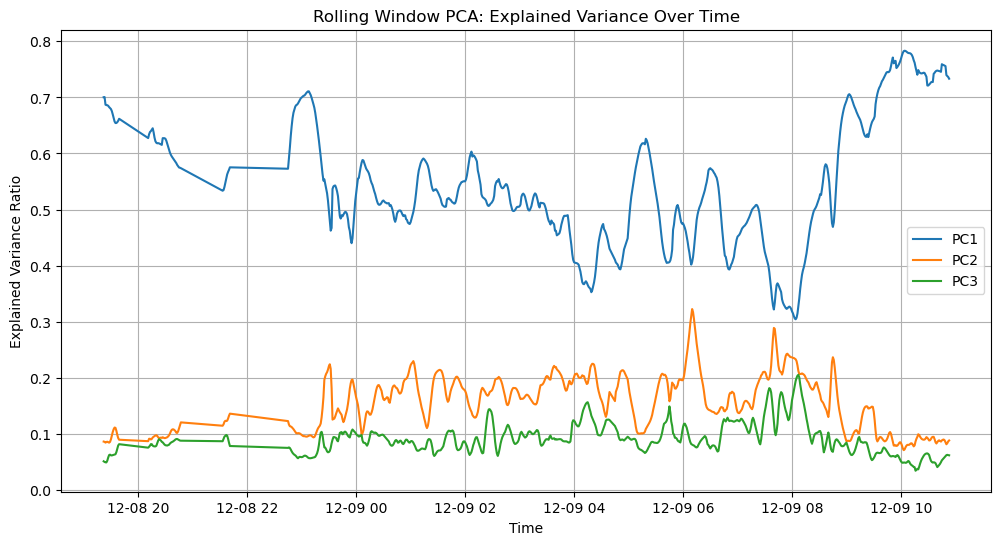

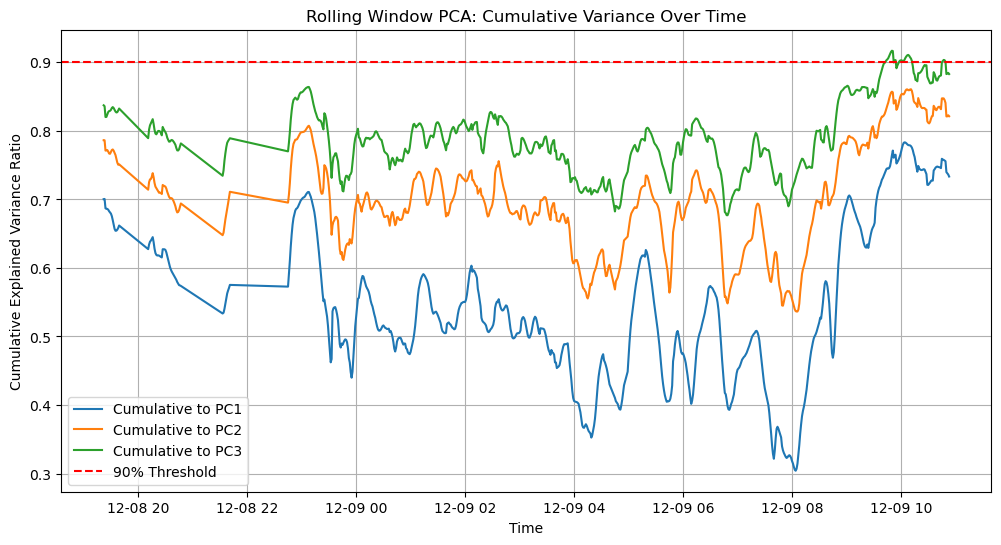

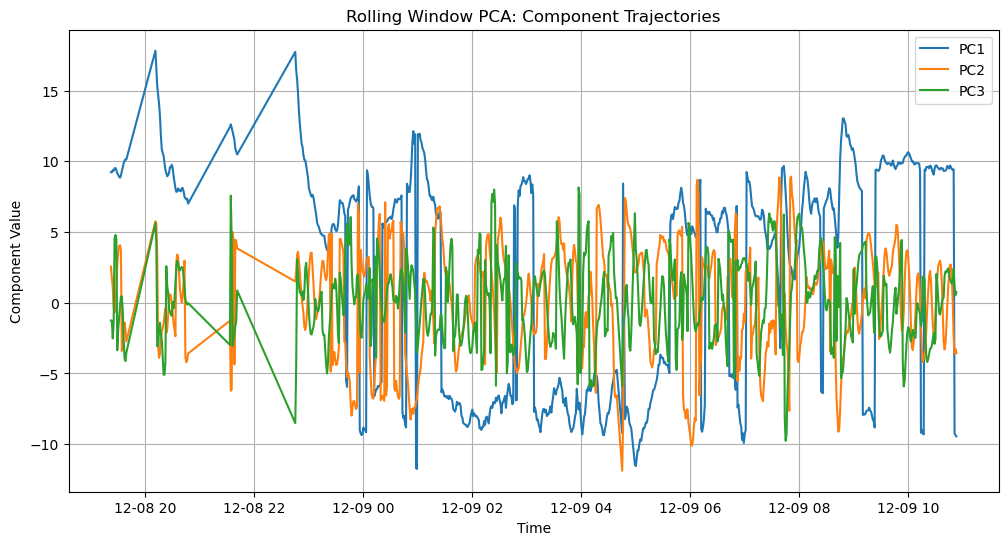

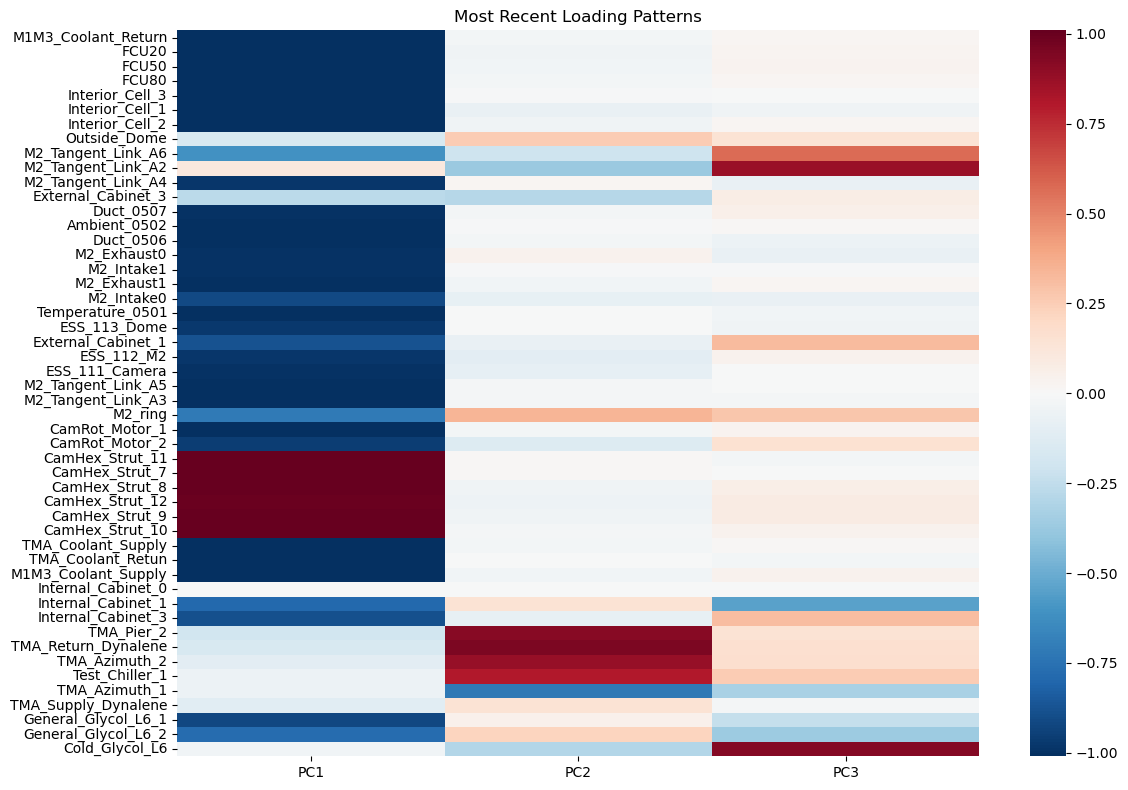

In [17]:
results_pca = analyze_temperature_series_pca(data_objects, window_size=50)

The details on the average variance explained by the PC1/PC2/PC3 components, including the top contributors by each component can be seen in the rolling_pca_analisis_report.txt file

## 4. Simonyi Temperature Sensor Model.
Let's focus in the relationships between all the temperature sensors and the three main temperature sensors tracing dome air temperature *(from now on called target sensor, i.e. ESS_113_Dome)*. We are interested in answering the question: "Which other temperature sensors are the most useful in predicting the temperature on the target sensor?  
For doing this we will do a multiple linear regression, combining multiple input sensors to predict the target sensor. 

The basic metrics to diagnose the validity of the model are summarized below:
* An R² score telling how well all other sensors together can predict the target sensor. High values will indicate that the model explains a high percentage of the variance in the target sensor.
* Root Mean Squared Error (RMSE) telling how far off the predictions typically are. Low MSE values will indicate high prediction accuracy.
* Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE) with low values indicating the amount in degress in which the predictions are off from the data.
* Residuals centered near zero with small standard deviation indicating no systematic bias.

It is also necesary to include Cross-Validation (CV) folding (k-fold spliting data into random train and test subsets) and handling regularization, to manage multicolinearity and to prevent overfitting. The basic metrics to diagnose the validity of the CV folding are summarized below:
* An CV-R² score indicating the model overall performance across all folds.
* An CV-std score with low values showing consistency in performance across the different data splits.
* Folds showing similar error patterns will be indicative of a robust model.

The model also shows the feature importance coefficients (without lag features) telling how much each sensor contributes to predicting the target. The bar chart will show which sensors have the strongest influence (positive or negative) on the target sensor.

Data loaded successfully
Time range: 2024-12-08 18:33:00+00:00 to 2024-12-09 10:53:00+00:00

Preparing data for analysis...

Training model...

Evaluating model performance...


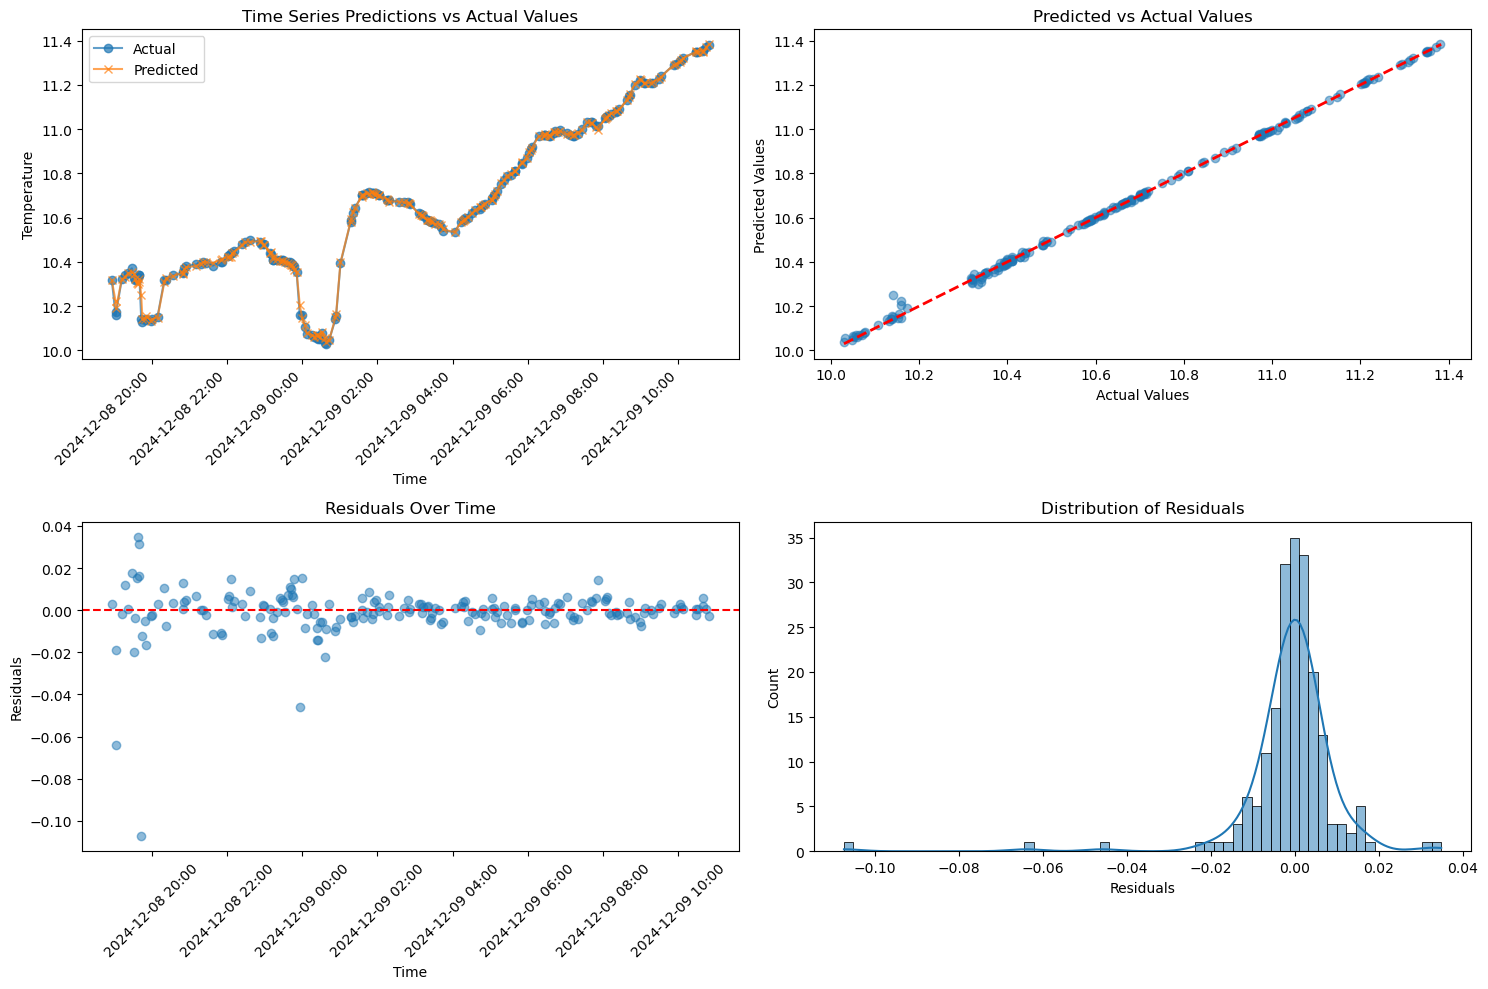


Residuals Statistics:
Mean of residuals: -0.0010
Std of residuals: 0.0119


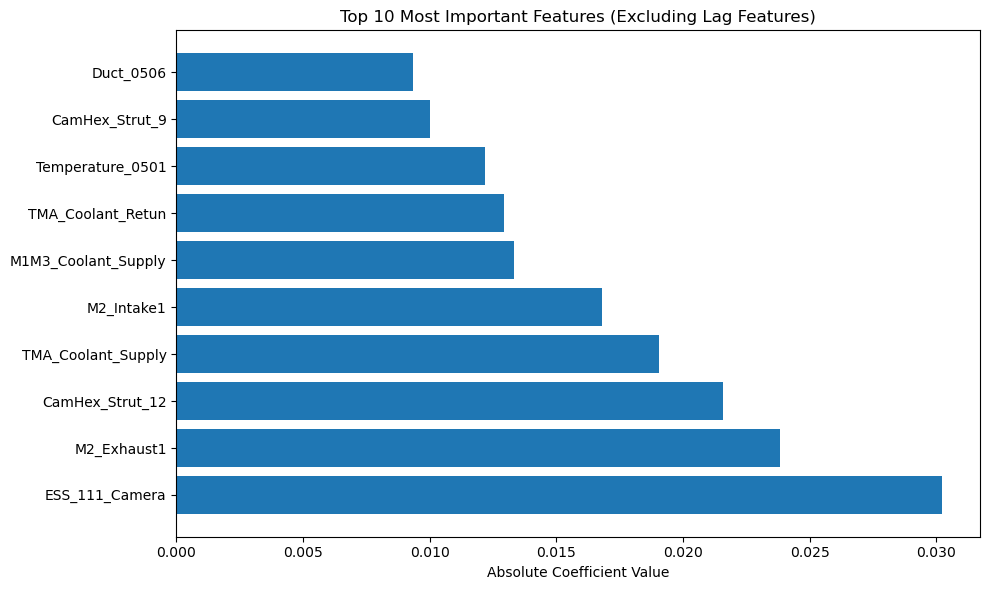


Top 10 Most Important Features (Excluding Lag Features):
ESS_111_Camera: 0.0302
M2_Exhaust1: 0.0238
CamHex_Strut_12: 0.0216
TMA_Coolant_Supply: 0.0190
M2_Intake1: 0.0168
M1M3_Coolant_Supply: 0.0133
TMA_Coolant_Retun: 0.0129
Temperature_0501: 0.0122
CamHex_Strut_9: 0.0100
Duct_0506: 0.0093

Model Evaluation Metrics:
RMSE: 0.0119
MAE: 0.0060
MAPE: 0.06%
R2 Score: 0.9989

Performing cross-validation...


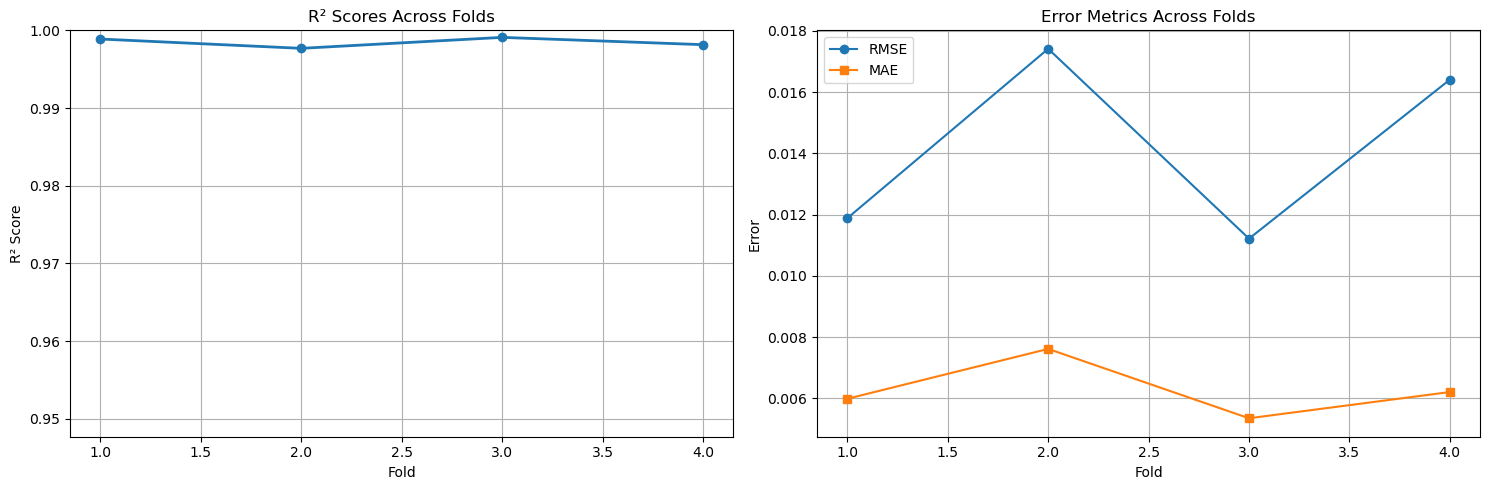


Detailed Cross-validation Results:

Per-fold metrics:
Fold 1:
  R² Score: 0.9989
  RMSE: 0.0119
  MAE: 0.0060
Fold 2:
  R² Score: 0.9977
  RMSE: 0.0174
  MAE: 0.0076
Fold 3:
  R² Score: 0.9991
  RMSE: 0.0112
  MAE: 0.0054
Fold 4:
  R² Score: 0.9982
  RMSE: 0.0164
  MAE: 0.0062

Cross-validation Results:
Mean R²: 0.9985 (±0.0006)



Would you like to see additional visualizations? (y/n):  y



Generating Additional Visualizations...

Error Distribution by Hour...


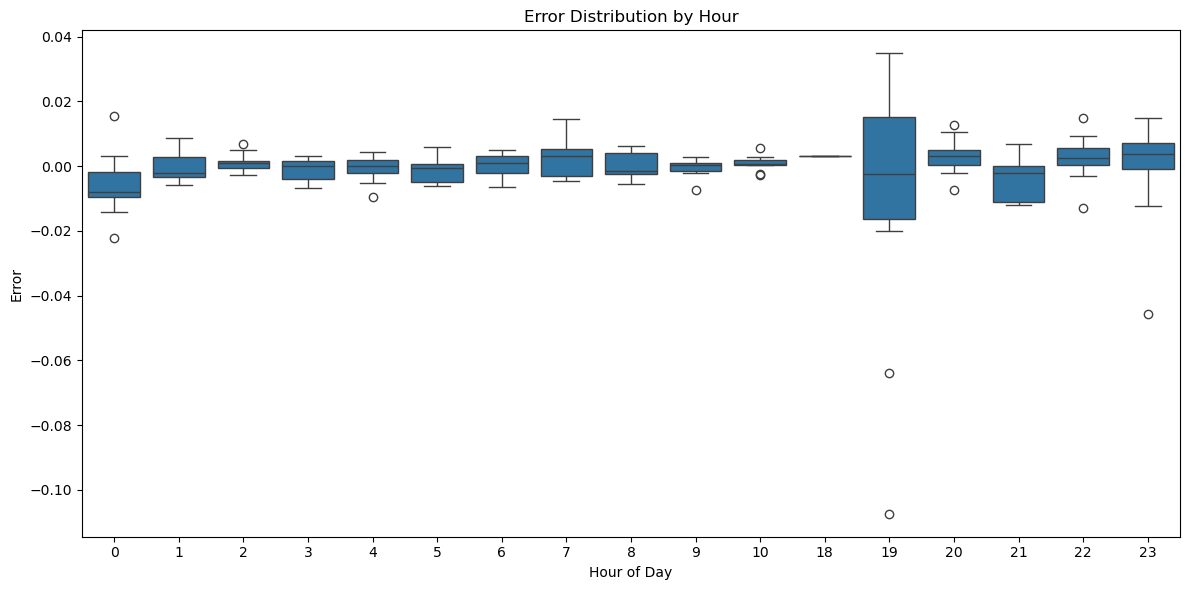


Enhanced Feature Pair Plots...


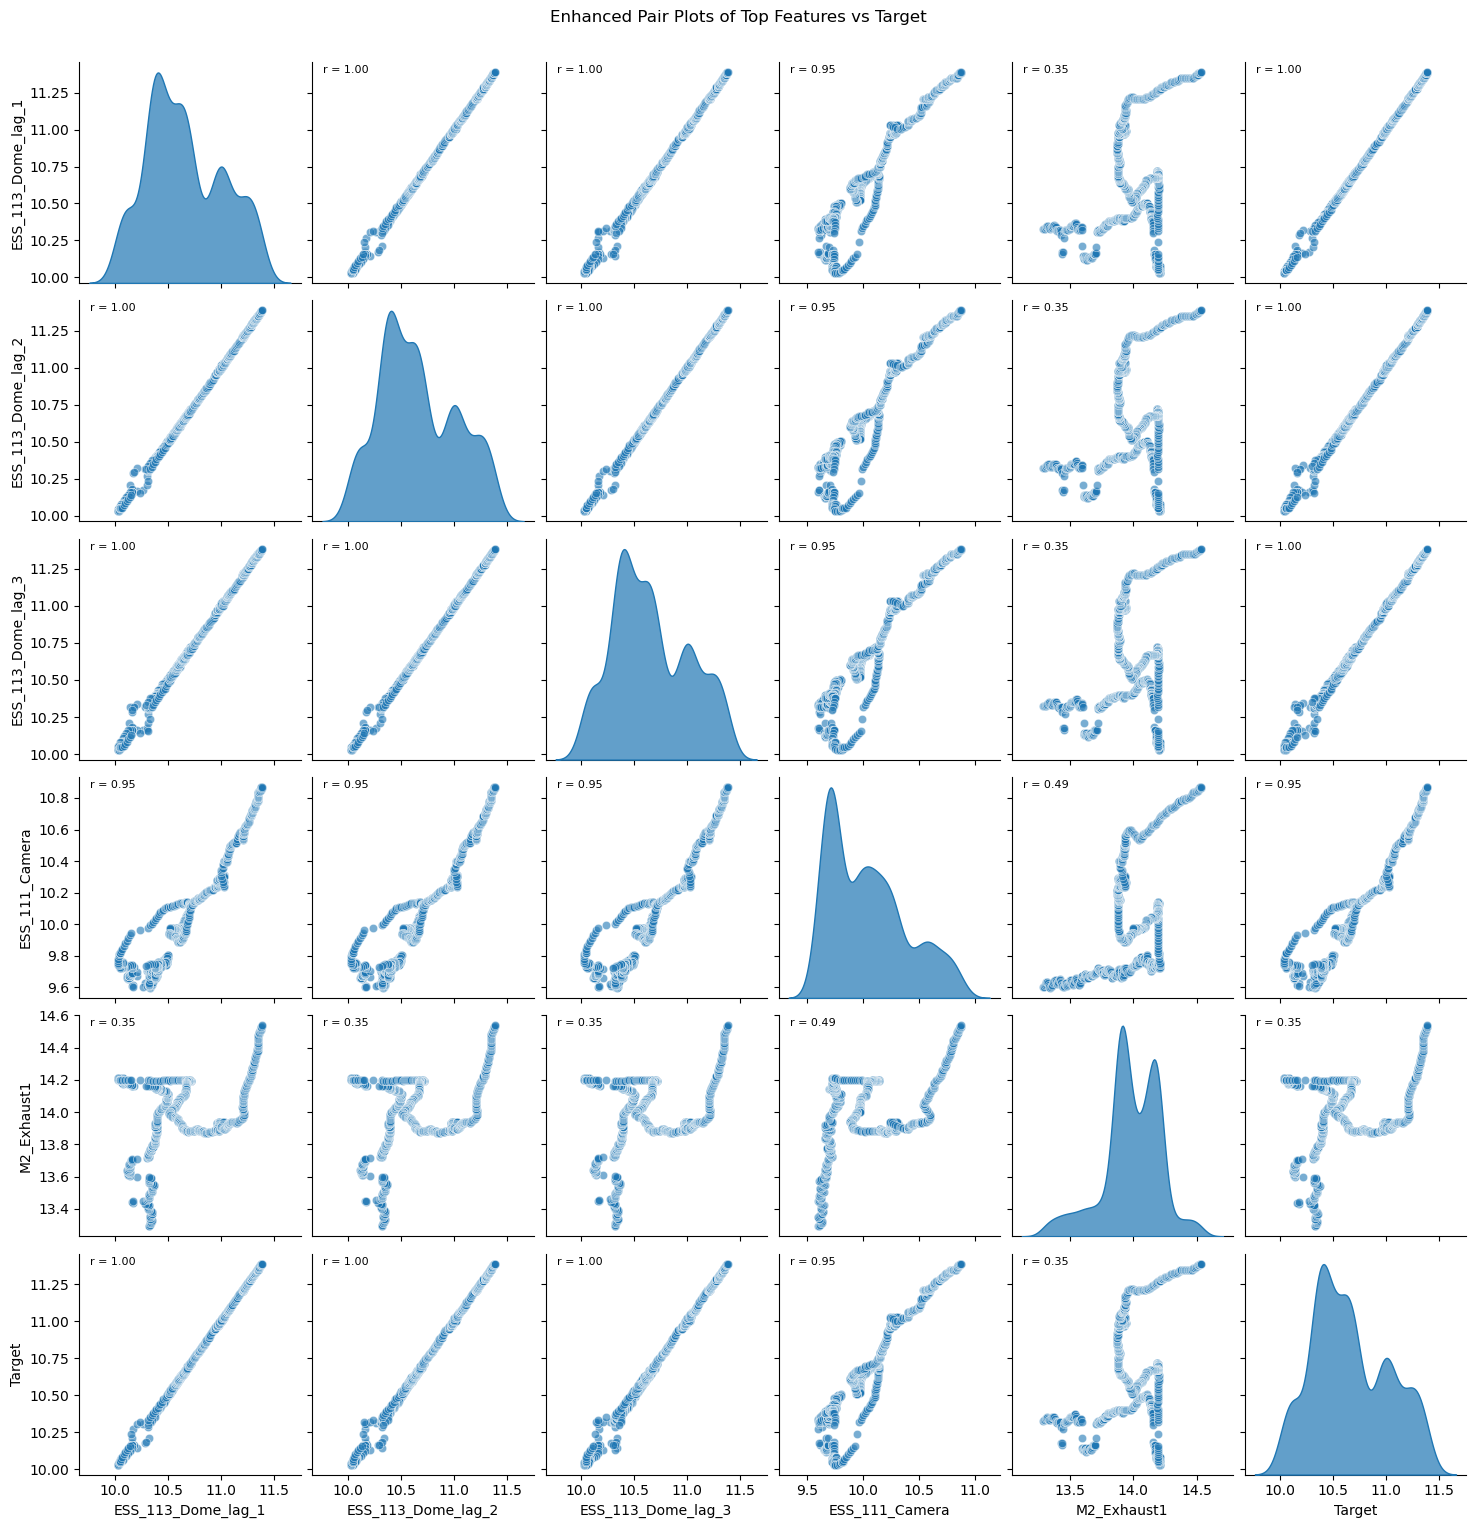


Feature Relationships Analysis:
--------------------------------------------------

ESS_113_Dome_lag_1 vs ESS_113_Dome_lag_2:
Correlation: 0.9996
Relationship: Strong

ESS_113_Dome_lag_1 vs ESS_113_Dome_lag_3:
Correlation: 0.9988
Relationship: Strong

ESS_113_Dome_lag_1 vs M2_Exhaust1:
Correlation: 0.3495
Relationship: Moderate

ESS_113_Dome_lag_1 vs Target:
Correlation: 0.9996
Relationship: Strong

ESS_113_Dome_lag_2 vs ESS_113_Dome_lag_3:
Correlation: 0.9996
Relationship: Strong

ESS_113_Dome_lag_2 vs M2_Exhaust1:
Correlation: 0.3494
Relationship: Moderate

ESS_113_Dome_lag_2 vs Target:
Correlation: 0.9988
Relationship: Strong

ESS_113_Dome_lag_3 vs M2_Exhaust1:
Correlation: 0.3492
Relationship: Moderate

ESS_113_Dome_lag_3 vs Target:
Correlation: 0.9978
Relationship: Strong

ESS_111_Camera vs ESS_113_Dome_lag_1:
Correlation: 0.9516
Relationship: Strong

ESS_111_Camera vs ESS_113_Dome_lag_2:
Correlation: 0.9504
Relationship: Strong

ESS_111_Camera vs ESS_113_Dome_lag_3:
Correlation:

In [18]:
#Simonyi temperature model.
#Assisted by claude 3.5 sonnet.
#Creation of lagged features from the (time series) target sensor: ESS_112_M2.
class LagFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='ESS_112_M2', lags=[1, 2, 3]):
        self.column = column
        self.lags = lags
        
    def fit(self, X, y=None):
        return self

    #Creation of 'target_sensor_lag_1/2/3' with values from 1/2/3 timestep ago
    def transform(self, X):
        X_copy = X.copy()
        original_index = X_copy.index
        
        for lag in self.lags:
            lag_name = f'{self.column}_lag_{lag}'
            X_copy[lag_name] = X_copy[self.column].shift(lag)
        
        X_copy = X_copy.fillna(method='ffill').fillna(method='bfill')
        X_copy.index = original_index
        return X_copy

#Scaling the data
def create_preprocessing_pipeline():
    return Pipeline([
        ('scaler', StandardScaler())
    ])

#Preprocessing data
def prepare_data(df, target_column='ESS_113_Dome', lags=[1, 2, 3]):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("DataFrame must have a DatetimeIndex")
    if target_column not in df.columns:
        raise ValueError(f"Target column {target_column} not found in DataFrame")
    #Applying the lagged function
    df_sorted = df.sort_index()
    lag_transformer = LagFeatureTransformer(column=target_column, lags=lags)
    df_with_lags = lag_transformer.transform(df_sorted)
    #Splits into features (X) and target (y)
    X = df_with_lags.copy()
    y = X.pop(target_column)
    
    return X, y

#Bar plot of most important features
def plot_feature_importance(pipeline, feature_names):
    model = pipeline.named_steps['regressor']
    importance = np.abs(model.coef_)
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    
    feature_importance = feature_importance[~feature_importance['Feature'].str.contains('_lag_')]
    feature_importance = feature_importance.nlargest(10, 'Importance')
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(feature_importance)), feature_importance['Importance'])
    plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
    plt.xlabel('Absolute Coefficient Value')
    plt.title('Top 10 Most Important Features (Excluding Lag Features)')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features (Excluding Lag Features):")
    for idx, row in feature_importance.iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")

#Ploting diagnostic metrics
def plot_diagnostics(y_test, y_pred, residuals):
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Residuals': residuals
    }, index=y_test.index)
    
    results_df = results_df.sort_index()
    
    fig = plt.figure(figsize=(15, 10))
    
    ax1 = plt.subplot(2, 2, 1)
    results_df['Actual'].plot(marker='o', label='Actual', ax=ax1, linestyle='-', alpha=0.7)
    results_df['Predicted'].plot(marker='x', label='Predicted', ax=ax1, linestyle='-', alpha=0.7)
    plt.title('Time Series Predictions vs Actual Values')
    plt.xlabel('Time')
    plt.ylabel('Temperature')
    plt.legend()
    ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 2)
    plt.scatter(results_df['Actual'], results_df['Predicted'], alpha=0.5)
    min_val = min(results_df['Actual'].min(), results_df['Predicted'].min())
    max_val = max(results_df['Actual'].max(), results_df['Predicted'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title('Predicted vs Actual Values')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    
    ax3 = plt.subplot(2, 2, 3)
    plt.scatter(results_df.index, results_df['Residuals'], alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals')
    ax3.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 4)
    sns.histplot(results_df['Residuals'], kde=True)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residuals')
    
    plt.tight_layout()
    plt.show()
    
    print("\nResiduals Statistics:")
    print(f"Mean of residuals: {results_df['Residuals'].mean():.4f}")
    print(f"Std of residuals: {results_df['Residuals'].std():.4f}")

#Spliting data, creating pipeline with scaling and Ridge regression
def train_model(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    pipeline = Pipeline([
        ('preprocessor', create_preprocessing_pipeline()),
        ('regressor', Ridge(alpha=1.0))
    ])
    
    pipeline.fit(X_train, y_train)
    
    return pipeline, X_train, X_test, y_train, y_test

#Diagnostic metrics
def evaluate_model(pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_pred = pd.Series(y_pred, index=y_test.index)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    residuals = y_test - y_pred
    
    plot_diagnostics(y_test, y_pred, residuals)
    
    feature_names = X_test.columns
    plot_feature_importance(pipeline, feature_names)
    
    return {
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'r2': r2,
        'residuals': residuals
    }

#Evaluationg model performance across different data splits
def perform_cross_validation(X, y, n_splits=4, test_size=0.2, random_state=42):
    shuffle_split = ShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )
    
    pipeline = Pipeline([
        ('preprocessor', create_preprocessing_pipeline()),
        ('regressor', Ridge(alpha=1.0))
    ])
    
    cv_scores = []
    cv_rmse = []
    cv_mae = []
    fold_metrics = []
    
    for fold, (train_idx, test_idx) in enumerate(shuffle_split.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        cv_scores.append(r2)
        cv_rmse.append(rmse)
        cv_mae.append(mae)
        
        fold_metrics.append({
            'fold': fold,
            'r2': r2,
            'rmse': rmse,
            'mae': mae
        })
    
    cv_scores = np.array(cv_scores)
    cv_rmse = np.array(cv_rmse)
    cv_mae = np.array(cv_mae)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(range(1, n_splits + 1), cv_scores, marker='o', linestyle='-', linewidth=2)
    ax1.set_title('R² Scores Across Folds')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('R² Score')
    ax1.grid(True)
    ax1.set_ylim([min(cv_scores) - 0.05, 1.0])
    
    ax2.plot(range(1, n_splits + 1), cv_rmse, marker='o', label='RMSE', linestyle='-')
    ax2.plot(range(1, n_splits + 1), cv_mae, marker='s', label='MAE', linestyle='-')
    ax2.set_title('Error Metrics Across Folds')
    ax2.set_xlabel('Fold')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\nDetailed Cross-validation Results:")
    print("\nPer-fold metrics:")
    for metrics in fold_metrics:
        print(f"Fold {metrics['fold']}:")
        print(f"  R² Score: {metrics['r2']:.4f}")
        print(f"  RMSE: {metrics['rmse']:.4f}")
        print(f"  MAE: {metrics['mae']:.4f}")
    
    return {
        'cv_scores': cv_scores,
        'cv_rmse': cv_rmse,
        'cv_mae': cv_mae,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'rmse_mean': cv_rmse.mean(),
        'rmse_std': cv_rmse.std(),
        'mae_mean': cv_mae.mean(),
        'mae_std': cv_mae.std(),
        'fold_metrics': fold_metrics
    }

#Additional plots
def generate_additional_visualizations(X, y, y_test, y_pred, residuals, feature_importance):
    print("\nGenerating Additional Visualizations...")
    
    #Error Distribution by Hour
    print("\nError Distribution by Hour...")
    results_df = pd.DataFrame({
        'Time': y_test.index,
        'Error': residuals,
        'Hour': y_test.index.hour
    })
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=results_df, x='Hour', y='Error')
    plt.title('Error Distribution by Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Error')
    plt.tight_layout()
    plt.show()
    
    #Enhanced Feature Pair Plots
    print("\nEnhanced Feature Pair Plots...")
    top_features = feature_importance['Feature'].head(5).tolist()
    
    plot_data = X[top_features].copy()
    plot_data['Target'] = y
    
    g = sns.pairplot(
        data=plot_data,
        diag_kind='kde',
        plot_kws={'alpha': 0.6},
        diag_kws={'alpha': 0.7}
    )
    
    for i in range(len(plot_data.columns)):
        for j in range(len(plot_data.columns)):
            if i != j:
                correlation = plot_data.iloc[:, [i, j]].corr().iloc[0, 1]
                g.axes[i, j].annotate(
                    f'r = {correlation:.2f}',
                    xy=(0.05, 0.95),
                    xycoords='axes fraction',
                    fontsize=8,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
                )
    
    plt.suptitle('Enhanced Pair Plots of Top Features vs Target', y=1.02)
    plt.show()
    
    print("\nFeature Relationships Analysis:")
    print("-" * 50)
    for feature1 in plot_data.columns:
        for feature2 in plot_data.columns:
            if feature1 < feature2:
                correlation = plot_data[feature1].corr(plot_data[feature2])
                print(f"\n{feature1} vs {feature2}:")
                print(f"Correlation: {correlation:.4f}")
                
                if abs(correlation) > 0.7:
                    strength = "Strong"
                elif abs(correlation) > 0.3:
                    strength = "Moderate"
                else:
                    strength = "Weak"
                
                print(f"Relationship: {strength}")

if __name__ == '__main__':
    try:
        #Load the data
        df = df
        
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        
        print("Data loaded successfully")
        print(f"Time range: {df.index.min()} to {df.index.max()}")
        
        #Prepare data for the entire time series
        print("\nPreparing data for analysis...")
        X, y = prepare_data(df)
        
        #Train model on the complete dataset
        print("\nTraining model...")
        pipeline, X_train, X_test, y_train, y_test = train_model(X, y)
        
        #Evaluate model
        print("\nEvaluating model performance...")
        metrics = evaluate_model(pipeline, X_test, y_test)
        
        print("\nModel Evaluation Metrics:")
        print(f"RMSE: {metrics['rmse']:.4f}")
        print(f"MAE: {metrics['mae']:.4f}")
        print(f"MAPE: {metrics['mape']:.2f}%")
        print(f"R2 Score: {metrics['r2']:.4f}")
        
        #Perform cross-validation
        print("\nPerforming cross-validation...")
        cv_results = perform_cross_validation(X, y)
        print("\nCross-validation Results:")
        print(f"Mean R²: {cv_results['cv_mean']:.4f} (±{cv_results['cv_std']:.4f})")
        
        #Generate additional visualizations
        show_additional_viz = input("\nWould you like to see additional visualizations? (y/n): ").lower() == 'y'
        if show_additional_viz:
            #Get feature importance data
            importance = np.abs(pipeline.named_steps['regressor'].coef_)
            feature_importance = pd.DataFrame({
                'Feature': X.columns,
                'Importance': importance
            }).sort_values('Importance', ascending=False)
            
            #Generate additional visualizations
            generate_additional_visualizations(
                X=X,
                y=y,
                y_test=y_test,
                y_pred=pipeline.predict(X_test),
                residuals=metrics['residuals'],
                feature_importance=feature_importance
            )
        
    except FileNotFoundError as e:
        print(f"Error: Could not find the data file\n{e}")
    except Exception as e:
        print(f"Error: An unexpected error occurred\n{e}")
        raise  #Full error traceback


## 5. Final remarks
Although this analysis mixes sensors that trace air and surface temperarure, it shows the possibility of having an overall perspective of the temperature sensors at Simonyi. In this specific case, we explore an historical analysis of the thermal conditions within the dome during the ComCam campaign. In Section 2, we show the temperature trends on specific sensors. In Section 3, a PCA over successive time windows was applied to analyze how the relationships between temperature sensors evolve over time on a daily basis. PC1 is capturing the strongest pattern of collective variation among all the sensors simultaneously. Finally, regression model focused on a target sensor (ESS_112_M2) daily values is presented. With this approach we are able to understanding collective patterns (PCA) and also, have a prediction model (Ridge).

In [19]:
#Reproducibility
print_session_info()

# Session Info on 2025-07-11 at 00:28:36 UTC

## Python Interpreter

Version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]  
Executable: /opt/lsst/software/stack/conda/envs/lsst-scipipe-10.0.0/bin/python3

## Science Pipelines

lsst_distrib         gdfb3db0272+f18f63b413 (w_2025_27 w_latest)
